# Network Intrusion Detection

### Comparing classifiers with the CIC-IDS2017 dataset

The goal of this project is to classify network flows as benign or malicious. The dataset contains flow statistics, not malware files, so I group every label other than `BENIGN` into one attack class.


## Setup

These imports are used for data preparation, charts, and model training.


In [1]:
from pathlib import Path
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)

# This lets the notebook run from either the project folder or notebooks/.
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data" / "raw"
MODELS_DIR = PROJECT_ROOT / "models"
MODELS_DIR.mkdir(exist_ok=True)

RANDOM_STATE = 42


## 1. Load the data

CIC-IDS2017 is provided as eight CSV files. I combine them into one DataFrame and remove the extra spaces in the column names.


In [2]:
csv_files = sorted(DATA_DIR.glob("*.csv"))
if not csv_files:
    raise FileNotFoundError(f"No CSV files found in {DATA_DIR}")

t0 = time.time()
frames = []
for file in csv_files:
    day = pd.read_csv(file, encoding="utf-8", low_memory=False)
    day.columns = day.columns.str.strip()
    frames.append(day)
    print(f"{file.name:55s} {day.shape}")

df = pd.concat(frames, ignore_index=True)
del frames
print(f"\nCombined shape: {df.shape}  ({time.time() - t0:.1f}s)")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1e6:.0f} MB")


Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv        (225745, 79)


Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv    (286467, 79)


Friday-WorkingHours-Morning.pcap_ISCX.csv               (191033, 79)


Monday-WorkingHours.pcap_ISCX.csv                       (529918, 79)


Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv (288602, 79)


Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv  (170366, 79)


Tuesday-WorkingHours.pcap_ISCX.csv                      (445909, 79)


Wednesday-workingHours.pcap_ISCX.csv                    (692703, 79)



Combined shape: (2830743, 79)  (22.6s)
Memory usage: 1923 MB


## 2. Clean the data

The raw data has a few issues: some labels contain a bad character, some numeric columns contain infinite values, and there are exact duplicate rows. I also convert the numeric columns to `float32` to reduce memory use.


In [3]:
df["Label"] = df["Label"].str.replace("�", "-", regex=False).str.strip()

num_cols = df.select_dtypes(include=[np.number]).columns
df[num_cols] = df[num_cols].astype("float32")

df[num_cols] = df[num_cols].replace([np.inf, -np.inf], np.nan)
n_before = len(df)
df = df.dropna(subset=num_cols)
print(f"Dropped {n_before - len(df):,} rows with inf/NaN values ({(n_before - len(df)) / n_before:.3%})")

n_before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f"Dropped {n_before - len(df):,} duplicate rows ({(n_before - len(df)) / n_before:.1%})")

print(f"\nFinal cleaned shape: {df.shape}")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1e6:.0f} MB")

Dropped 2,867 rows with inf/NaN values (0.101%)


Dropped 329,896 duplicate rows (11.7%)

Final cleaned shape: (2497980, 79)
Memory usage: 917 MB


## 3. Explore the labels

Before changing the problem to binary classification, I checked how many flows belong to each original label. A log scale makes the smaller attack groups easier to see.


Label
BENIGN                        2072254
DoS Hulk                       172846
DDoS                           128014
PortScan                        90694
DoS GoldenEye                   10282
FTP-Patator                      5931
DoS slowloris                    5374
DoS Slowhttptest                 5228
SSH-Patator                      3219
Bot                              1948
Web Attack - Brute Force         1470
Web Attack - XSS                  652
Infiltration                       36
Web Attack - Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64


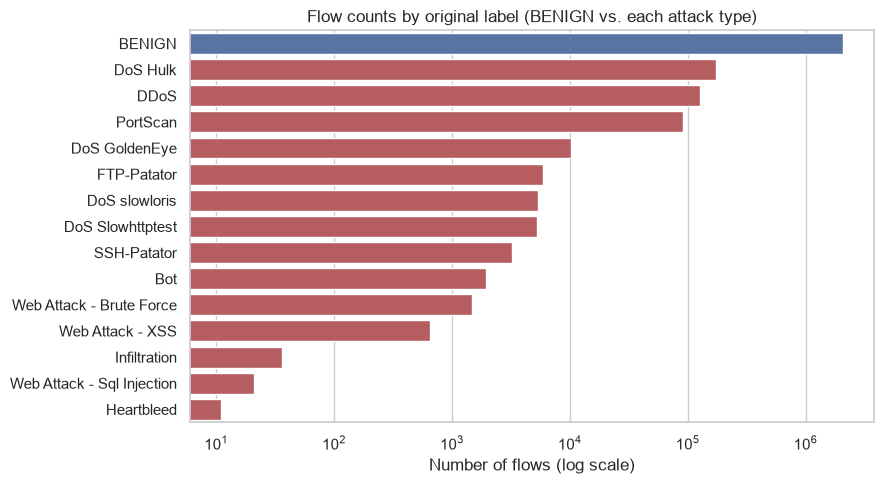

In [4]:
label_counts = df["Label"].value_counts()
print(label_counts)

fig, ax = plt.subplots(figsize=(9, 5))
order = label_counts.index
colors = ["#4C72B0" if l == "BENIGN" else "#C44E52" for l in order]
sns.barplot(x=label_counts.values, y=order, hue=order, palette=colors, legend=False, ax=ax)
ax.set_xscale("log")
ax.set_xlabel("Number of flows (log scale)")
ax.set_ylabel("")
ax.set_title("Flow counts by original label (BENIGN vs. each attack type)")
plt.tight_layout()
plt.show()

### Binary target

For the models, `0` means benign and `1` means malicious. The split is uneven, so I use class weights during training and look at precision and recall in addition to accuracy.


Label
Benign       0.829572
Malicious    0.170428
Name: proportion, dtype: float64


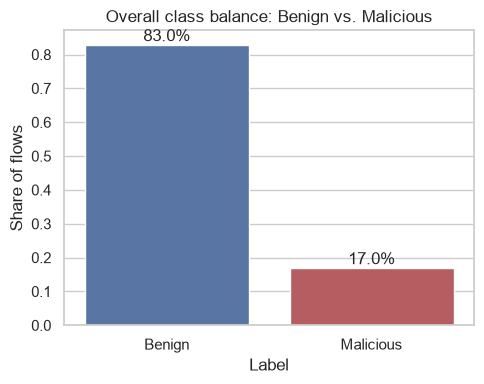


Feature matrix shape: (2497980, 78)


In [5]:
CLASS_NAMES = ["Benign", "Malicious"]

y = (df["Label"] != "BENIGN").astype(int)
X = df.drop(columns=["Label"])

balance = y.value_counts(normalize=True).rename(index={0: "Benign", 1: "Malicious"})
print(balance)

fig, ax = plt.subplots(figsize=(5, 4))
sns.barplot(x=balance.index, y=balance.values, hue=balance.index,
            palette=["#4C72B0", "#C44E52"], legend=False, ax=ax)
ax.set_ylabel("Share of flows")
ax.set_title("Overall class balance: Benign vs. Malicious")
for i, v in enumerate(balance.values):
    ax.text(i, v + 0.01, f"{v:.1%}", ha="center")
plt.tight_layout()
plt.show()

print(f"\nFeature matrix shape: {X.shape}")

## 4. Prepare training and test data

I keep 20% of the rows for testing and stratify the split so the class ratio stays the same. Logistic regression needs scaled features; the two tree models use the original values.


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train class balance:\n{y_train.value_counts(normalize=True)}")

Train: (1998384, 78), Test: (499596, 78)
Train class balance:
Label
0    0.829572
1    0.170428
Name: proportion, dtype: float64


## 5. Train the models

I compare logistic regression as a simple baseline with random forest and XGBoost. The same training and test rows are used for all three models.


In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

trained = {}  # name -> dict(model, uses_scaled, y_pred, y_proba, train_time)


def train_and_predict(name, model, uses_scaled):
    Xtr = X_train_scaled if uses_scaled else X_train
    Xte = X_test_scaled if uses_scaled else X_test

    t0 = time.time()
    model.fit(Xtr, y_train)
    train_time = time.time() - t0

    y_pred = model.predict(Xte)
    y_proba = model.predict_proba(Xte)[:, 1]

    trained[name] = dict(
        model=model, uses_scaled=uses_scaled,
        y_pred=y_pred, y_proba=y_proba, train_time=train_time,
    )
    print(f"{name}: trained in {train_time:.1f}s")

In [8]:
log_reg = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE)
train_and_predict("Logistic Regression", log_reg, uses_scaled=True)


Logistic Regression: trained in 62.7s


In [9]:
rand_forest = RandomForestClassifier(
    n_estimators=200, class_weight="balanced_subsample",
    n_jobs=-1, random_state=RANDOM_STATE,
)
train_and_predict("Random Forest", rand_forest, uses_scaled=False)

Random Forest: trained in 427.7s


In [10]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()  # balances XGBoost the way class_weight does for sklearn

xgb_clf = xgb.XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.1,
    scale_pos_weight=scale_pos_weight, eval_metric="logloss",
    tree_method="hist", n_jobs=-1, random_state=RANDOM_STATE,
)
train_and_predict("XGBoost", xgb_clf, uses_scaled=False)

XGBoost: trained in 123.1s


## 6. Evaluate the models

I compare accuracy, precision, recall, F1 score, and ROC-AUC. F1 is the main comparison metric because it accounts for both false alarms and missed attacks.


In [11]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix,
    roc_curve, precision_recall_curve,
)

metrics_rows = []
for name, info in trained.items():
    y_pred, y_proba = info["y_pred"], info["y_proba"]
    metrics_rows.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba),
        "Train time (s)": info["train_time"],
    })
    print(f"=== {name} ===")
    print(classification_report(y_test, y_pred, target_names=CLASS_NAMES, digits=4))

=== Logistic Regression ===


              precision    recall  f1-score   support

      Benign     0.9948    0.9325    0.9627    414451
   Malicious     0.7483    0.9762    0.8472     85145

    accuracy                         0.9400    499596
   macro avg     0.8715    0.9544    0.9049    499596
weighted avg     0.9528    0.9400    0.9430    499596



=== Random Forest ===


              precision    recall  f1-score   support

      Benign     0.9990    0.9992    0.9991    414451
   Malicious     0.9962    0.9951    0.9957     85145

    accuracy                         0.9985    499596
   macro avg     0.9976    0.9972    0.9974    499596
weighted avg     0.9985    0.9985    0.9985    499596



=== XGBoost ===


              precision    recall  f1-score   support

      Benign     0.9999    0.9989    0.9994    414451
   Malicious     0.9949    0.9997    0.9973     85145

    accuracy                         0.9991    499596
   macro avg     0.9974    0.9993    0.9984    499596
weighted avg     0.9991    0.9991    0.9991    499596



### Confusion matrices

The lower-left square shows malicious flows that the model missed.


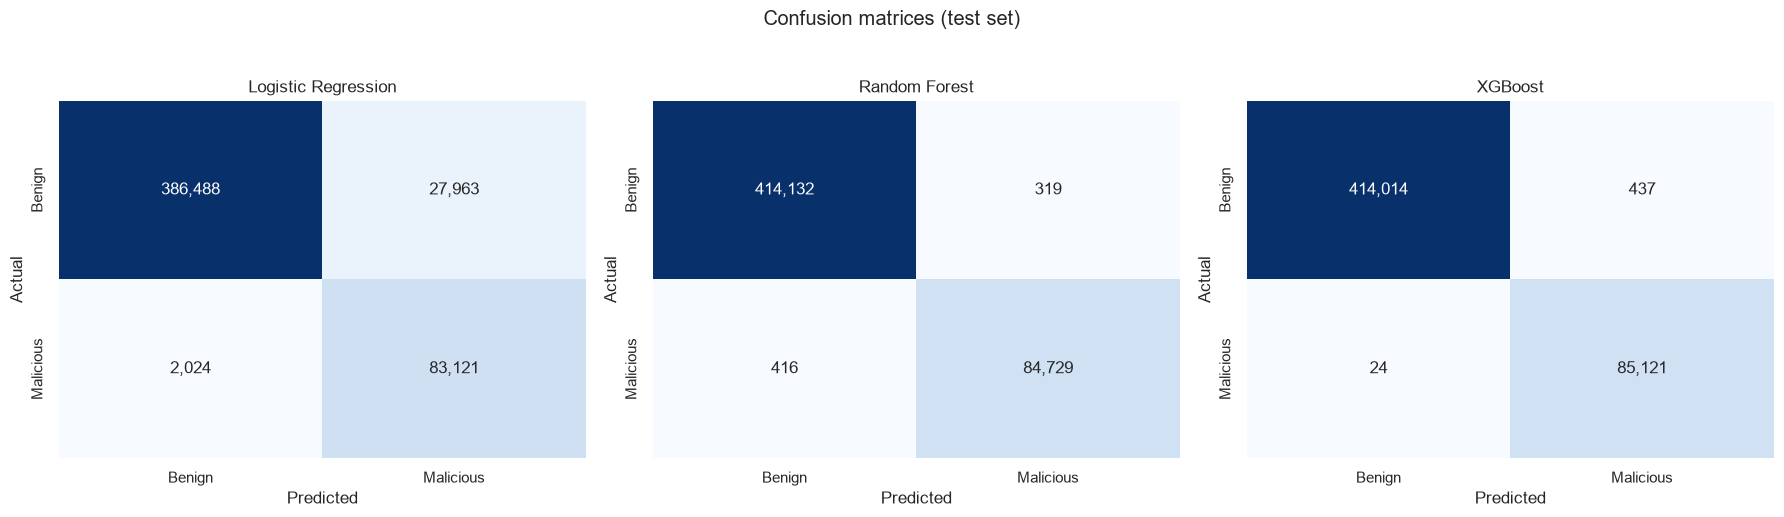

In [12]:
fig, axes = plt.subplots(1, len(trained), figsize=(6 * len(trained), 5))
if len(trained) == 1:
    axes = [axes]

for ax, (name, info) in zip(axes, trained.items()):
    cm = confusion_matrix(y_test, info["y_pred"])
    sns.heatmap(
        cm, annot=True, fmt=",d", cmap="Blues", cbar=False, ax=ax,
        xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
    )
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.suptitle("Confusion matrices (test set)", y=1.03)
plt.tight_layout()
plt.show()

### Detection rate by attack type

The confusion matrices above only show Benign vs. Malicious, so a model can look excellent overall while still missing an entire attack category. Since the original `Label` column (before binarization) has the specific attack type for every malicious flow, and `train_test_split` preserves the DataFrame index, I can recover each test row's original attack type with `df.loc[X_test.index, "Label"]` and compare it against each model's existing predictions — no retraining needed.

In [13]:
test_labels = df.loc[X_test.index, "Label"]

rows = []
for attack_type in label_counts.index:
    if attack_type == "BENIGN":
        continue
    mask = (test_labels == attack_type).to_numpy()
    support = mask.sum()
    if support == 0:
        continue
    for name, info in trained.items():
        detected = info["y_pred"][mask].sum()
        rows.append({
            "Attack type": attack_type,
            "Model": name,
            "Support": int(support),
            "Detected": int(detected),
            "Missed": int(support - detected),
            "Detection rate": detected / support,
        })

detection_df = pd.DataFrame(rows)
pivot_rate = detection_df.pivot(index="Attack type", columns="Model", values="Detection rate")
pivot_rate = pivot_rate.reindex(label_counts.drop("BENIGN").index.intersection(pivot_rate.index))
support_by_type = detection_df.drop_duplicates("Attack type").set_index("Attack type")["Support"].reindex(pivot_rate.index)

display(pivot_rate.assign(Support=support_by_type).style.format(
    {**{c: "{:.2%}" for c in pivot_rate.columns}, "Support": "{:,.0f}"}
).background_gradient(subset=pivot_rate.columns, cmap="RdYlGn", vmin=0, vmax=1))

Model,Logistic Regression,Random Forest,XGBoost,Support
DoS Hulk,99.45%,99.74%,99.99%,"34,592"
DDoS,99.92%,99.97%,99.99%,"25,636"
PortScan,98.66%,98.94%,99.99%,"18,219"
DoS GoldenEye,90.20%,99.90%,99.95%,"1,999"
FTP-Patator,66.90%,100.00%,100.00%,"1,148"
DoS slowloris,91.20%,99.72%,100.00%,"1,079"
DoS Slowhttptest,87.75%,99.50%,100.00%,"1,004"
SSH-Patator,92.68%,99.38%,100.00%,642
Bot,24.27%,75.73%,97.60%,375
Web Attack - Brute Force,0.00%,98.11%,99.37%,317


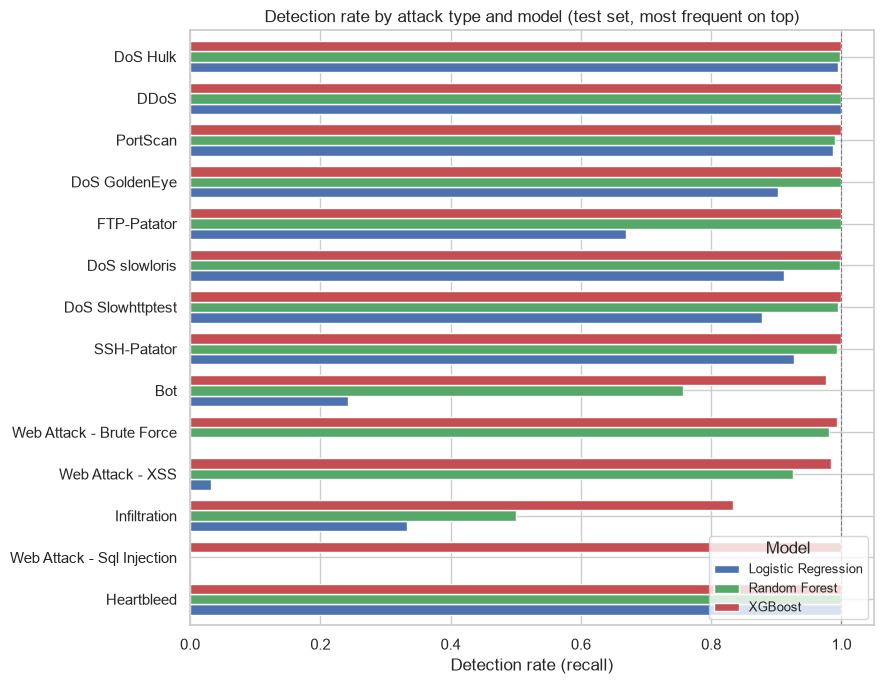

In [14]:
fig, ax = plt.subplots(figsize=(9, 7))
pivot_rate.iloc[::-1].plot(kind="barh", ax=ax, width=0.75, color=["#4C72B0", "#55A868", "#C44E52"])
ax.set_xlim(0, 1.05)
ax.set_xlabel("Detection rate (recall)")
ax.set_ylabel("")
ax.set_title("Detection rate by attack type and model (test set, most frequent on top)")
ax.legend(title="Model", loc="lower right", fontsize=9)
ax.axvline(1.0, color="grey", linewidth=0.8, linestyle="--")
plt.tight_layout()
plt.show()

A few attack types have single-digit support in the test split (e.g. Heartbleed ≈ 2 rows, Infiltration ≈ 7 rows, Web Attack - Sql Injection ≈ 4 rows, out of the 20% held out) because they were already rare in the full dataset (see Section 3). A 100% or 0% detection rate on that few rows isn't a reliable estimate of real-world performance — it mainly signals whether the model saw *any* examples of that attack type during training, not how well it generalizes to it. This is consistent with the notebook's Conclusion, which already flags class imbalance and suggests a multi-class model as a further step; this section makes the impact of that imbalance visible per attack type using the models already trained above.

### ROC and precision-recall curves

These curves compare the models across different decision thresholds instead of only using the default threshold.


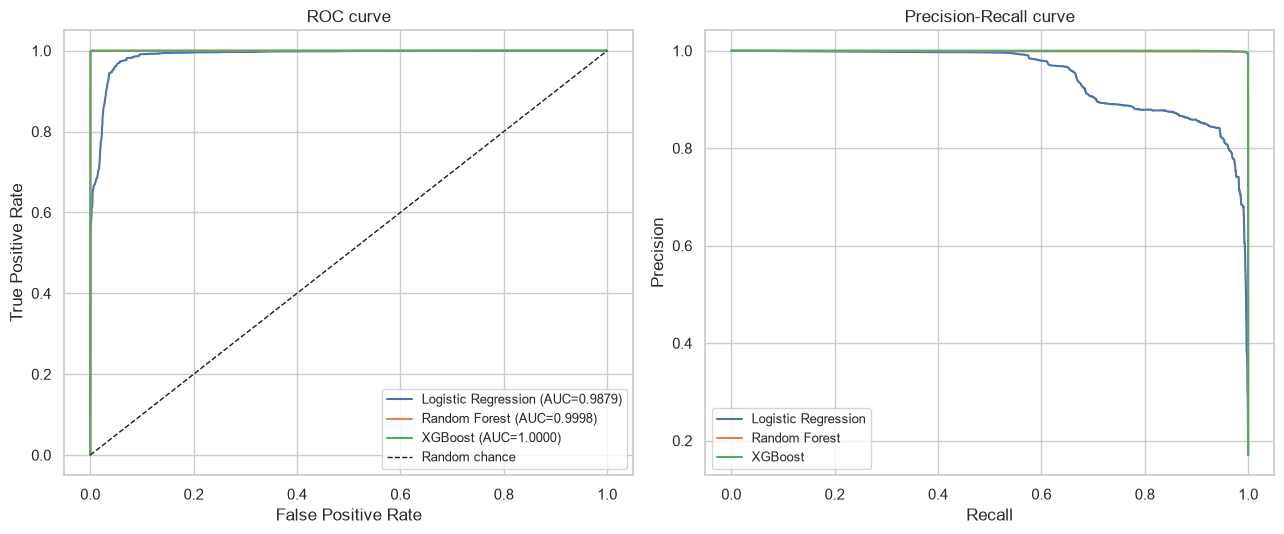

In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.5))

for name, info in trained.items():
    fpr, tpr, _ = roc_curve(y_test, info["y_proba"])
    ax1.plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test, info['y_proba']):.4f})")

    prec, rec, _ = precision_recall_curve(y_test, info["y_proba"])
    ax2.plot(rec, prec, label=name)

ax1.plot([0, 1], [0, 1], "k--", linewidth=1, label="Random chance")
ax1.set_xlabel("False Positive Rate")
ax1.set_ylabel("True Positive Rate")
ax1.set_title("ROC curve")
ax1.legend(loc="lower right", fontsize=9)

ax2.set_xlabel("Recall")
ax2.set_ylabel("Precision")
ax2.set_title("Precision-Recall curve")
ax2.legend(loc="lower left", fontsize=9)

plt.tight_layout()
plt.show()

### Results

The table ranks the models by F1 score.


In [16]:
comparison_df = pd.DataFrame(metrics_rows).set_index("Model").sort_values("F1", ascending=False)
display(comparison_df.style.format({
    "Accuracy": "{:.4%}", "Precision": "{:.4%}", "Recall": "{:.4%}",
    "F1": "{:.4%}", "ROC-AUC": "{:.4%}", "Train time (s)": "{:.1f}",
}).background_gradient(subset=["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"], cmap="Greens"))

BEST_MODEL_NAME = comparison_df["F1"].idxmax()
best_info = trained[BEST_MODEL_NAME]
print(f"\nBest model by F1 score: {BEST_MODEL_NAME}")

,Accuracy,Precision,Recall,F1,ROC-AUC,Train time (s)
Model,,,,,,
XGBoost,99.9077%,99.4892%,99.9718%,99.7299%,99.9981%,123.1
Random Forest,99.8529%,99.6249%,99.5114%,99.5681%,99.9802%,427.7
Logistic Regression,93.9978%,74.8272%,97.6229%,84.7184%,98.7904%,62.7



Best model by F1 score: XGBoost


## 7. Feature importance

The tree models can estimate which flow features contributed most to their decisions. These scores are useful for comparison, but they do not prove that a feature causes an attack.


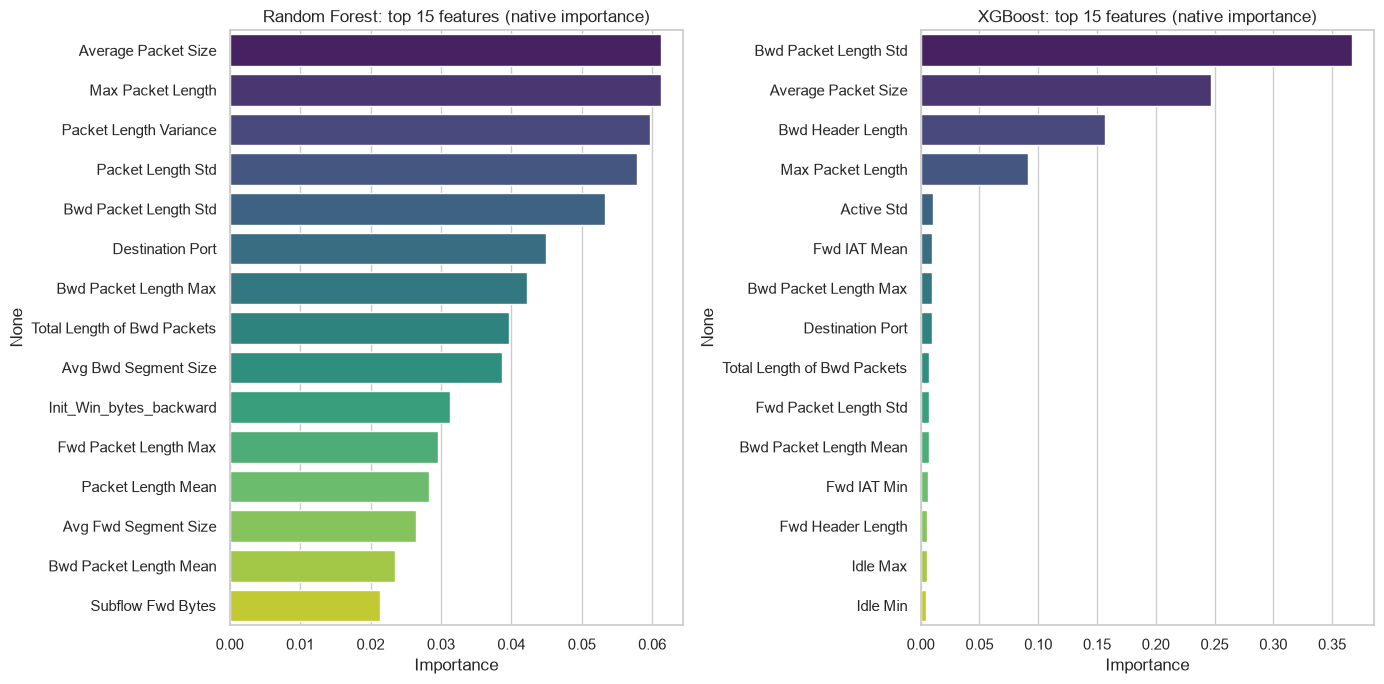

In [17]:
tree_models = {n: i for n, i in trained.items() if hasattr(i["model"], "feature_importances_")}

fig, axes = plt.subplots(1, len(tree_models), figsize=(7 * len(tree_models), 7))
if len(tree_models) == 1:
    axes = [axes]

for ax, (name, info) in zip(axes, tree_models.items()):
    importances = pd.Series(info["model"].feature_importances_, index=X.columns)
    top = importances.sort_values(ascending=False).head(15)
    sns.barplot(x=top.values, y=top.index, hue=top.index, palette="viridis", legend=False, ax=ax)
    ax.set_title(f"{name}: top 15 features (native importance)")
    ax.set_xlabel("Importance")

plt.tight_layout()
plt.show()

## 8. Save the best model

The last step saves the best model, its feature order, and the scaler so it can be loaded again later.


In [18]:
import joblib

artifact = {
    "model": best_info["model"],
    "model_name": BEST_MODEL_NAME,
    "uses_scaled": best_info["uses_scaled"],
    "scaler": scaler,
    "feature_columns": list(X.columns),
    "class_names": CLASS_NAMES,
}

out_path = MODELS_DIR / "intrusion_detector.joblib"
joblib.dump(artifact, out_path)
print(f"Saved best model ({BEST_MODEL_NAME}) to {out_path}")
print(f"File size: {out_path.stat().st_size / 1e6:.1f} MB")

Saved best model (XGBoost) to C:\Users\armen\Documents\Martin Personal\Martin Projects\Javascript Projects\Network Intrusion Detection\models\intrusion_detector.joblib
File size: 0.9 MB


## Conclusion

XGBoost performed best on the test split, with 99.91% accuracy and a 99.73% F1 score for malicious traffic. Random forest was close behind. Logistic regression found most attacks, but its lower precision caused more false alarms.

The high scores should be treated carefully. CIC-IDS2017 was collected in a lab, and a random split is easier than testing on traffic from a different day or network. A useful next step would be a day-based test split or a multi-class model that predicts the attack type.
